In [1]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [3]:
G = nx.powerlaw_cluster_graph(n=169, m=1, p=0.1)

In [4]:
results_dir = "erdos_renyi_n=169_m=1_p=0.1_num_runs_10"
os.mkdir(results_dir)

In [5]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [6]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
it_searcher = IterativeSearcher(adv_sampler)

In [7]:
results = it_searcher.run_with_sampleset_info(num_runs=10, saving_path=f"{results_dir}/", return_metadata=True)

 80%|████████  | 8/10 [16:29<03:51, 115.62s/it]

Error while saving HierarchicalRunMetadata (sampleset_data) from iteration: 7 


 80%|████████  | 8/10 [16:30<04:07, 123.76s/it]


IndexError: list index out of range

In [2]:
import pickle
import os
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields


path = "./erdos_renyi_n=169_m=1_p=0.1_num_runs_10/"

field_names = [f.name for f in fields(HierarchicalRunMetadata)]


sampleset_metadatas = []

print("Loading files...")

for run in range(7):
    hierarchical_run_metadata = HierarchicalRunMetadata.load_from_files(f"{path}_{run}")
    sampleset_metadatas.append(hierarchical_run_metadata)

Loading files...
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable


In [3]:
import numpy as np


communities = np.load(f"{path}_communities.npy", allow_pickle=True)
modularities = np.load(f"{path}_modularities.npy", allow_pickle=True)
division_modularities = np.load(f"{path}_division_modularities.npy", allow_pickle=True)

In [4]:
mods = []
cbf_max = []
cbf_avg = []
non_zero_cbfs = []
chain_strengths = []
comms_lens = []
energies = []
indices = []

for idx, sm in enumerate(sampleset_metadatas):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max.append(cbfs.max())
    cbf_avg.append(cbfs.mean())
    non_zero_cbfs.append(cbfs[non_zero_cbfs_idxs])
    indices.append(non_zero_cbfs_idxs)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    comms_lens.append(communities[idx])

In [5]:
for i, (indices, nonzero) in enumerate(zip(indices, non_zero_cbfs)):
    chain_strengths = np.round(np.array(sampleset_metadatas[i].chain_strength, dtype=float), 4)
    print(f"CBF: {nonzero} at idx: {indices} of the hierarchical tree in run: {i} with chain_strenghts: {chain_strengths[indices]}")

CBF: [0.07100592] at idx: (array([0]),) of the hierarchical tree in run: 0 with chain_strenghts: [0.9805]
CBF: [0.08284024] at idx: (array([0]),) of the hierarchical tree in run: 1 with chain_strenghts: [0.9805]
CBF: [0.0887574] at idx: (array([0]),) of the hierarchical tree in run: 2 with chain_strenghts: [0.9805]
CBF: [0.03550296] at idx: (array([0]),) of the hierarchical tree in run: 3 with chain_strenghts: [0.9805]
CBF: [0.09467456] at idx: (array([0]),) of the hierarchical tree in run: 4 with chain_strenghts: [0.9805]
CBF: [0.07100592 0.02222222] at idx: (array([ 0, 39]),) of the hierarchical tree in run: 5 with chain_strenghts: [0.9805 0.8649]
CBF: [0.08284024 0.01265823] at idx: (array([0, 1]),) of the hierarchical tree in run: 6 with chain_strenghts: [0.9805 0.8778]


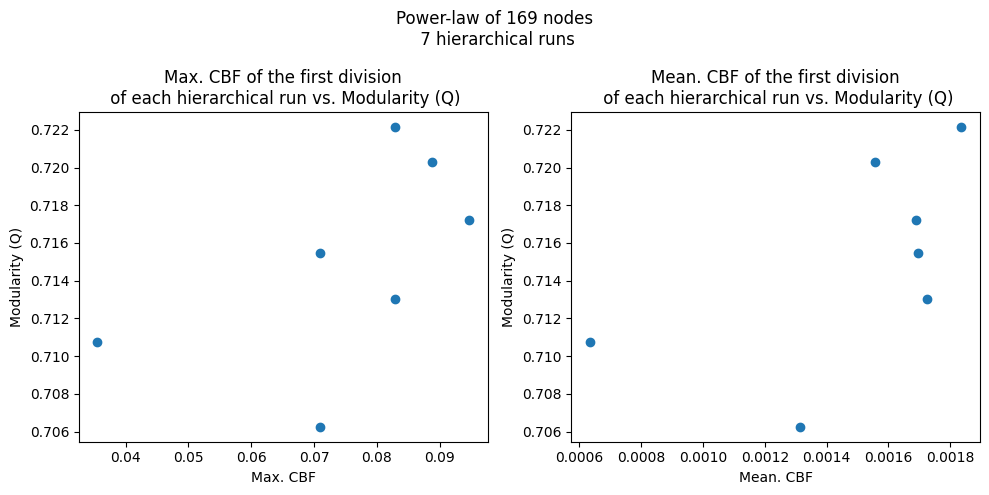

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Power-law of 169 nodes\n 7 hierarchical runs")

ax[0].scatter(cbf_max, mods)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

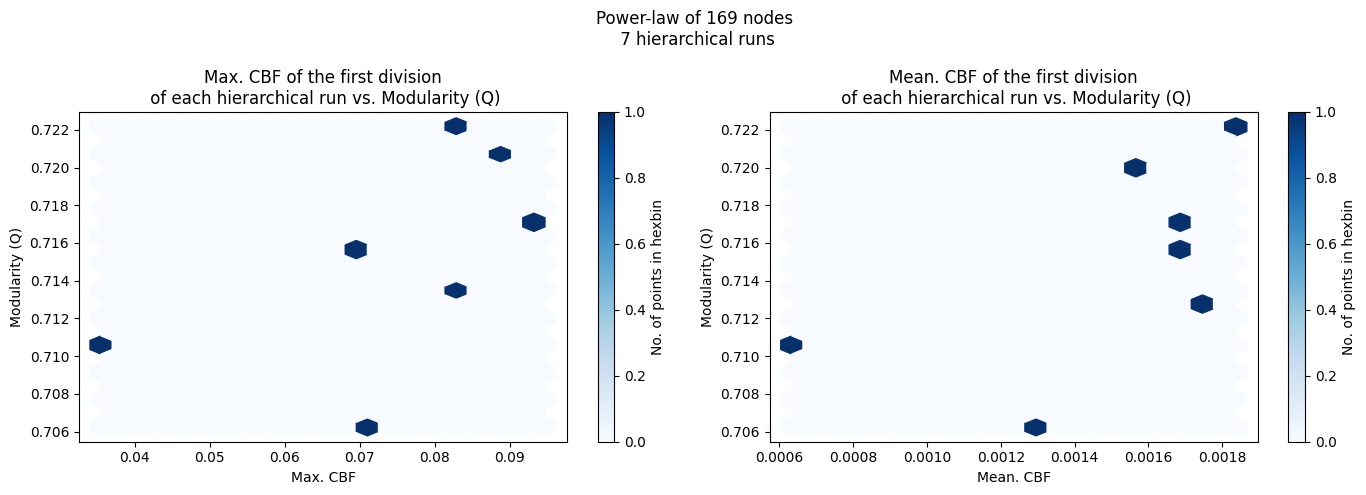

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Power-law of 169 nodes\n 7 hierarchical runs")

hb_0 = ax[0].hexbin(cbf_max, mods, cmap="Blues", gridsize=20)
cb = fig.colorbar(hb_0, ax=ax[0])
cb.set_label("No. of points in hexbin")
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

hb_1 = ax[1].hexbin(cbf_avg, mods, cmap="Blues", gridsize=20)
cb = fig.colorbar(hb_1, ax=ax[1])
cb.set_label("No. of points in hexbin")
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()